# 6. Actuator-grid DM with baked-in misalignment

The `actuator_grid` corrector is an N×N influence-function deformable mirror driven by **raw per-actuator commands** — the command surface a hardware DM actually exposes, as opposed to the modal (Zernike) interface of the `zernike` corrector. Two influence models are available (`gaussian` and `xinetics`, via the matching HCIPy factories), and DM **misalignment relative to the pupil is baked in at construction**: `rotation_deg` rotates the influence-function geometry, `flip_x`/`flip_y` mirror the command-array indexing (a mirrored cable/mapping). That makes this corrector the natural simulation stand-in for a real bench DM whose mounting and wiring a calibration routine must recover.

Command conventions (pinned by the unit tests):

- `set_actuators` accepts a flat `(N²,)` or shaped `(N, N)` array;
  a shaped command indexes `cmd[iy, ix]` — axis 0 walks y ascending,
  axis 1 walks x ascending.
- Positive `rotation_deg` rotates the DM **counterclockwise**
  relative to the pupil (x right, y up) as seen in a plotted
  surface.
- Flips mirror the command indexing *before* the rotated geometry
  renders it (**flip-then-rotate**), and the `actuators` readback
  un-applies them, so callers always round-trip their own values.

This demo uses a realistic scale: a 50×50 actuator grid at 0.17 m projected pitch over an 8 m circular pupil (2500 actuators on a 256² grid — the influence-function basis is sparse, and building it takes a few seconds at bind time).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import hcipy

from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

config = {
    'pupil': {'resolution': 256, 'extent': 8.65},
    'aperture': {
        'type': 'external_pupil', 'mode': 'callable',
        'module': 'hcipy', 'function': 'make_circular_aperture',
        'kwargs': {'diameter': 8.0},
        'area': float(np.pi * 4.0 ** 2),
    },
    'correctors': {
        'dm': {
            'type': 'actuator_grid',
            'num_actuators': 50,
            'actuator_pitch': 0.17,
            'influence': 'gaussian',
            'rotation_deg': 3.5,
            'actuate_scale': 1.0e-6,   # caller units -> meters of surface
            'wavefront_role': 'actuate',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['dm'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 1.55e-6,
            'focal_extent': 1.6, 'focal_res': 128,
            'fractional_bandwidth': 0.0, 'num_samples': 1,
        },
    },
    'outputs': {
        'psf': {
            'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
            'post_processing': [],
        },
    },
}
sim = build(SimConfig.model_validate(config))
dm = sim.correctors['dm']
print('n_actuators:', dm.n_actuators)


n_actuators: 2500


Poke two actuators (0.12 command units × `actuate_scale` = 120 nm of surface each) and sample. The OPD panel shows the two localized influence-function bumps; the PSF picks up the corresponding speckle structure.

Strehl at rest: 1.000
Strehl poked:   0.998


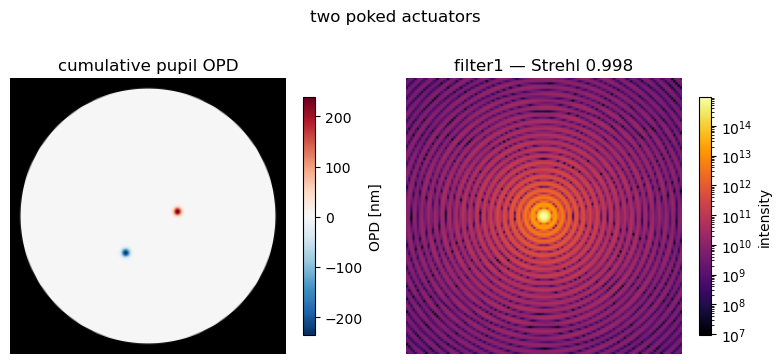

In [2]:
cmd = np.zeros((50, 50))
cmd[25, 30] = 0.12   # cmd[iy, ix]: y index 25, x index 30
cmd[18, 20] = -0.12

out_rest = sim.sample(meas_strehl=True, meas_pupil_opd=True)
out_poke = sim.sample(
    actuations={'dm': cmd}, meas_strehl=True, meas_pupil_opd=True,
)
print(f"Strehl at rest: {out_rest['strehls']['filter1']:.3f}")
print(f"Strehl poked:   {out_poke['strehls']['filter1']:.3f}")
plot_opd_and_psfs(sim, out_poke, suptitle='two poked actuators')
plt.show()


## Misalignment: rotation and command flips

To make the conventions visible, render one asymmetric command pattern (a blocky letter **F** — unambiguous under both rotations and mirror flips) through three DM variants: aligned, rotated, and rotated + `flip_x`. The correctors are constructed directly and bound to the sim's existing pupil grid — the same call the YAML loader makes at build time.

In the aligned panel the F reads normally (axis 0 of the command is y, so the top bar of the F is at high y). With `rotation_deg=10` the whole surface turns counterclockwise. Adding `flip_x` mirrors the command indexing first, then the rotated geometry renders it — flip-then-rotate.

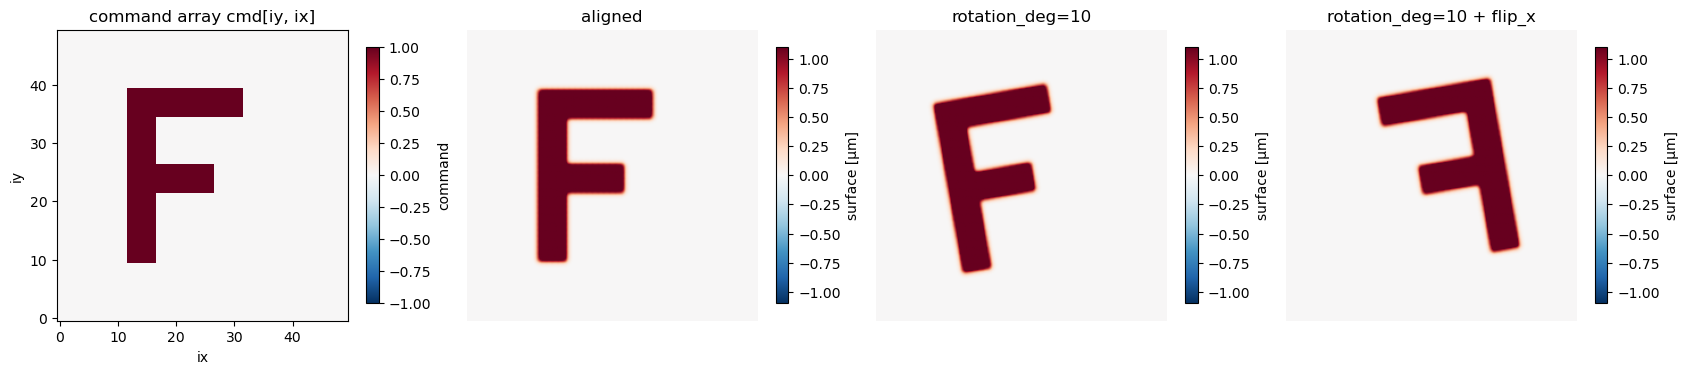

In [3]:
from telescope_sim.correctors.actuator_grid import ActuatorGridCorrector

cmd_f = np.zeros((50, 50))
cmd_f[10:40, 12:17] = 1.0   # vertical stroke
cmd_f[35:40, 12:32] = 1.0   # top bar (high y)
cmd_f[22:27, 12:27] = 1.0   # middle bar

pupil_grid = sim.aperture.field.grid
variants = [
    ('aligned', {}),
    ('rotation_deg=10', {'rotation_deg': 10.0}),
    ('rotation_deg=10 + flip_x', {'rotation_deg': 10.0, 'flip_x': True}),
]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
im0 = axes[0].imshow(
    cmd_f, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1,
)
axes[0].set_title('command array cmd[iy, ix]')
axes[0].set_xlabel('ix')
axes[0].set_ylabel('iy')
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='command')

for ax, (label, kwargs) in zip(axes[1:], variants):
    dm_i = ActuatorGridCorrector(50, 0.17, actuate_scale=1.0e-6, **kwargs)
    dm_i._bind_pupil_grid(pupil_grid, sim.aperture.field)
    dm_i.set_actuators(cmd_f)
    plt.sca(ax)
    # (Tutorial code reaches into ._dm for the surface; library
    # code shouldn't.)
    im = hcipy.imshow_field(
        dm_i._dm.surface * 1e6, cmap='RdBu_r', vmin=-1.1, vmax=1.1,
    )
    ax.set_title(label)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='surface [µm]')
plt.tight_layout()
plt.show()


The readback stays in the caller's frame — with flips active the DM-facing command is mirrored, but `dm.actuators` returns exactly what was set:

In [4]:
dm_flipped = ActuatorGridCorrector(
    50, 0.17, actuate_scale=1.0e-6, flip_x=True, flip_y=True,
)
dm_flipped._bind_pupil_grid(pupil_grid, sim.aperture.field)
dm_flipped.set_actuators(cmd_f)
print('round-trip exact:',
      np.allclose(dm_flipped.actuators, cmd_f.reshape(-1)))


round-trip exact: True


## Influence models: `gaussian` vs `xinetics`

`gaussian` builds Gaussian pokes with a configurable nearest-neighbour `crosstalk` (default 0.15); `xinetics` uses HCIPy's measured Xinetics actuator shape. Both accept the same misalignment parameters. A single poked actuator on a small demo grid shows the difference in footprint.

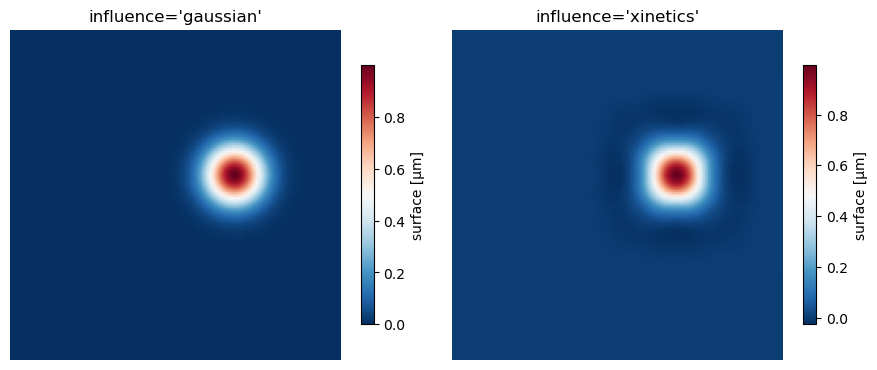

In [5]:
mini_grid = hcipy.make_pupil_grid(128, 1.05)
mini_aper = hcipy.evaluate_supersampled(
    hcipy.make_circular_aperture(1.0), mini_grid, 4,
)
poke = np.zeros((8, 8))
poke[4, 5] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, influence in zip(axes, ['gaussian', 'xinetics']):
    dm_i = ActuatorGridCorrector(
        8, 1.0 / 8, influence=influence, actuate_scale=1.0e-6,
    )
    dm_i._bind_pupil_grid(mini_grid, mini_aper)
    dm_i.set_actuators(poke)
    plt.sca(ax)
    im = hcipy.imshow_field(dm_i._dm.surface * 1e6, cmap='RdBu_r')
    ax.set_title(f'influence={influence!r}')
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='surface [µm]')
plt.tight_layout()
plt.show()


## Notes for real-DM workflows

- `actuate_scale` carries the caller-units → meters-of-surface
  calibration; commands stay in the units your control software
  already uses.
- Building the influence basis dominates sim construction (a few
  seconds for 50×50 on a 256² grid); per-sample cost is
  sub-millisecond. Build once, sample many times.
- `fit_surface` (fit-role / residual-fit participation) is
  deliberately not implemented for this corrector — see tutorial 5
  for a custom corrector that adds it.
